In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv("creditcard.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'creditcard.csv'

In [4]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\hp\CreditCardFraudDetection
['.ipynb_checkpoints', 'CreditCardFraudDetection.ipynb.ipynb']


In [5]:
df = pd.read_csv(r"C:\Users\hp\Documents\CreditCardFraudDetection\creditcard.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\hp\\Documents\\CreditCardFraudDetection\\creditcard.csv'

In [6]:
import pandas as pd

df = pd.read_csv(r"C:\Users\hp\Downloads\archive (4)\fraudTrain.csv")

df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [7]:
# Check dataset size
df.shape

(1296675, 23)

In [8]:
# See all column names
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='str')

In [9]:
# Check data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last                   1296675 non-null  str    
 8   gender                 1296675 non-null  str    
 9   street                 1296675 non-null  str    
 10  city                   1296675 non-null  str    
 11  state                  1296675 non-null  str    
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long                   129667

In [10]:
# Check for null values
df.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [11]:
# See fraud distribution (important)
df['is_fraud'].value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

In [12]:
drop_cols = [
    'Unnamed: 0',
    'trans_date_trans_time',
    'cc_num',
    'first',
    'last',
    'street'
]

df = df.drop(columns=drop_cols)

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

C:\Users\hp\AppData\Local\Temp\ipykernel_28344\3207929033.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [14]:
df.head()


,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,514,8,4.97,0,526,27,28654,36.0788,-81.1781,3495,370,779,56438,1325376018,36.011293,-82.048315,0
1,241,4,107.23,0,612,47,99160,48.8878,-118.2105,149,428,607,159395,1325376044,49.159047,-118.186462,0
2,390,0,220.11,1,468,13,83252,42.1808,-112.2620,4154,307,302,818703,1325376051,43.150704,-112.154481,0
3,360,2,45.00,1,84,26,59632,46.2306,-112.1138,1939,328,397,544575,1325376076,47.034331,-112.561071,0
4,297,9,41.96,1,216,45,24433,38.4207,-79.4629,99,116,734,831111,1325376186,38.674999,-78.632459,0


In [15]:
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

In [16]:
print(X.shape)
print(y.shape)

(1296675, 16)
(1296675,)


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
print(X_train.shape)
print(X_test.shape)

(1037340, 16)
(259335, 16)


In [19]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

In [20]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=20,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",20
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)
print(cm)

NameError: name 'pred' is not defined

In [ ]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

print(importance.sort_values('Importance', ascending=False).head(10))

In [22]:
from sklearn.metrics import accuracy_score, classification_report

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.9976593980758478
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.89      0.68      0.77      1501

    accuracy                           1.00    259335
   macro avg       0.94      0.84      0.88    259335
weighted avg       1.00      1.00      1.00    259335



In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)
print(cm)

[[257708    126]
 [   481   1020]]


In [24]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

print(importance.sort_values('Importance', ascending=False).head(10))

       Feature  Importance
2          amt    0.441498
1     category    0.136083
13   unix_time    0.056172
11         dob    0.045313
14   merch_lat    0.040678
12   trans_num    0.038261
9     city_pop    0.038024
15  merch_long    0.037546
0     merchant    0.033929
4         city    0.023621


In [25]:
import joblib

joblib.dump(model, "fraud_detection_model.pkl")

print("Model saved successfully!")

Model saved successfully!


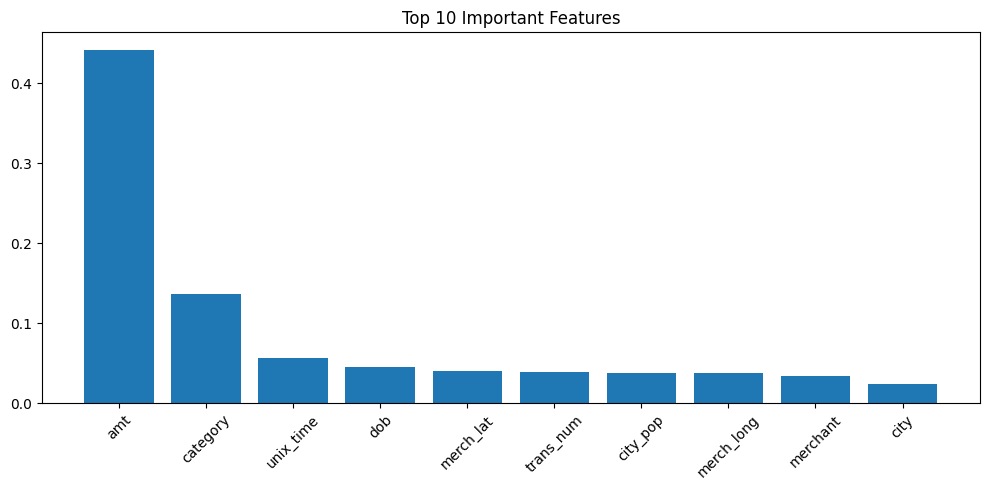

In [26]:
import matplotlib.pyplot as plt

top10 = importance.sort_values(
    'Importance',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))
plt.bar(top10['Feature'], top10['Importance'])
plt.xticks(rotation=45)
plt.title("Top 10 Important Features")
plt.tight_layout()
plt.show()

In [27]:
File → Save Notebook

SyntaxError: invalid character '→' (U+2192) (2673100875.py, line 1)

In [28]:
import os
print(os.getcwd())

C:\Users\hp\CreditCardFraudDetection


In [29]:
import joblib

joblib.dump(model, "fraud_detection_model.pkl")

['fraud_detection_model.pkl']

In [30]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'CreditCardFraudDetection.ipynb.ipynb', 'fraud_detection_model.pkl']


In [31]:
import os

print(os.getcwd())

C:\Users\hp\CreditCardFraudDetection
